# Transient Temperature Simulation in an Open District Heating Network

This tutorial demonstrates a transient temperature simulation of a simple open district heating network with pandapipes.

The network consists of:

- one external grid,
- three pipes,
- two consumers,
- and four junctions.

The goal of this example is to show how the temperature propagates through the network over time and how the system slowly approaches a stationary thermal state.

# Network Structure

The following figure shows the topology of the network used in this example.

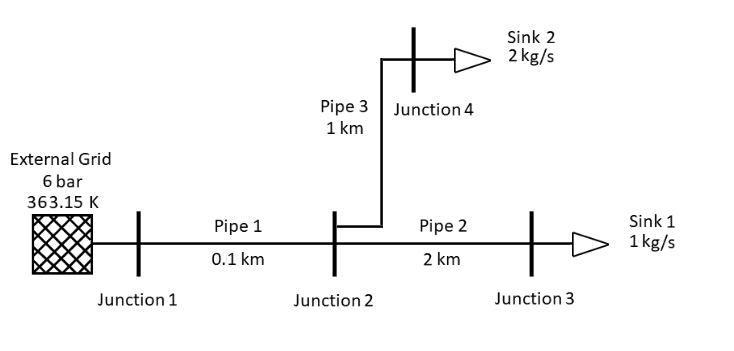

# Import Required Modules

First, pandapipes and the required libraries are imported.

In [13]:
import pandapipes as pp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
from matplotlib.collections import LineCollection
from pandapipes.component_models import Pipe
from pandapipes.timeseries.run_time_series import run_timeseries, _call_output_writer
from pandapower.timeseries.output_writer import OutputWriter
import tempfile

# Network Creation

An empty network with water as working fluid is created.

In [14]:
net = pp.create_empty_network("net", fluid="water")

# Junctions

Four junctions are created.
Initially, the complete network starts with a temperature of 20 °C.

In [15]:
junction1 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 1")
junction2 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 2")
junction3 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 3")
junction4 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Junction 4")

# External Grid

The external grid continuously feeds hot water with a temperature of 90 °C into the network.

In [16]:
pp.create_ext_grid(net, junction=junction1, p_bar=6, t_k=363.15, name="External Grid", type="pt")

np.int64(0)

# Consumers

Two sinks are used as thermal consumers. They remove mass flow from the network.

In [17]:
pp.create_sink(net, junction=junction3, mdot_kg_per_s=1, name="Sink 1")
pp.create_sink(net, junction=junction4, mdot_kg_per_s=2, name="Sink 2")

np.int64(1)

# Pipes

Three pipes are used to connect the junctions.

The parameter sections is important for the transient simulation.

Each pipe is internally divided into several sections. This allows pandapipes to calculate and visualize the temperature distribution inside the pipes.

In [18]:
pp.create_pipe_from_parameters(net, from_junction=junction1, to_junction=junction2, length_km=0.1, inner_diameter_mm=75, k_mm=0.025, sections=5, u_w_per_m2k=0.2, text_k=273.15 + 10, name="Pipe 1")

pp.create_pipe_from_parameters(net, from_junction=junction2, to_junction=junction3, length_km=2, inner_diameter_mm=50, k_mm=0.025, sections=4, u_w_per_m2k=0.2, text_k=273.15 + 10, name="Pipe 2")

pp.create_pipe_from_parameters(net, from_junction=junction2, to_junction=junction4, length_km=1, inner_diameter_mm=100, k_mm=0.025, sections=8, u_w_per_m2k=0.2, text_k=273.15 + 10, name="Pipe 3")

np.int64(2)

## Visualization Function

In [19]:
def plot_temperature_snapshot(net, time_s):
    cmap = plt.cm.coolwarm
    norm = mcolors.Normalize(vmin=293.15, vmax=363.15)

    coords = {
        0: (0.0, 0.0),     # Junction 1
        1: (1.0, 0.0),     # Junction 2
        2: (2.0, 0.6),     # Junction 3
        3: (2.0, -0.6),    # Junction 4
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    for pipe_idx in net.pipe.index:
        from_j = net.pipe.at[pipe_idx, "from_junction"]
        to_j = net.pipe.at[pipe_idx, "to_junction"]

        x0, y0 = coords[from_j]
        x1, y1 = coords[to_j]

        pipe_results = Pipe.get_internal_results(net, [pipe_idx])
        tinit = pipe_results["TINIT"]

        internal_temps = tinit[:, 1] if tinit.ndim == 2 else tinit

        t_from = net.res_junction.at[from_j, "t_k"]
        t_to = net.res_junction.at[to_j, "t_k"]
        temps = np.r_[t_from, internal_temps, t_to]

        xs = np.linspace(x0, x1, len(temps))
        ys = np.linspace(y0, y1, len(temps))

        points = np.array([xs, ys]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        segment_temps = (temps[:-1] + temps[1:]) / 2

        lc = LineCollection(
            segments,
            cmap=cmap,
            norm=norm,
            linewidth=3
        )
        lc.set_array(segment_temps)
        ax.add_collection(lc)

        ax.scatter(xs, ys, c=temps, cmap=cmap, norm=norm, s=45, zorder=3)

    for j, (x, y) in coords.items():
        temp = net.res_junction.at[j, "t_k"]
        ax.scatter(x, y, c=[temp], cmap=cmap, norm=norm,
                   s=120, edgecolor="black", zorder=4)
        ax.text(x, y + 0.08, f"J{j+1}", ha="center")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="Temperature [K]")

    ax.set_title(f"Temperature distribution with pipe sections at t = {time_s} s", pad= 20)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.show()

### Time Series Settings and Transient Simulation

In this part, the time settings for the transient simulation are defined.
The time step is set to 60 seconds, and the total simulation time is 9000 seconds. Therefore, pandapipes calculates the network state every 60 seconds.

An OutputWriter is used to store the simulation results at each time step. In this example, the junction temperatures, junction pressures, and pipe inlet and outlet temperatures are saved.

The custom output writer calls the default pandapipes output writer during every time step. It can also be used to print results or create temperature plots at selected times.

Finally, the time series simulation is started with `run_timeseries`. The simulation is performed in `sequential` mode. This means that pandapipes calculates the hydraulic state and then the thermal state in every time step.

The option `transient=True` activates the time-dependent temperature calculation, and `dt=60` defines the time step size used in the transient heat equation.

In [ ]:
dt = 60
t_end = 9000

time_steps = range(0, t_end + dt, dt)

plot_times_s = {
    60, 300,1200, 2400,
    3600, 4500,
}

ow = OutputWriter(
    net,
    time_steps=time_steps,
    output_path=tempfile.gettempdir(),
    log_variables=[]
)

ow.log_variable("res_junction", "t_k")
ow.log_variable("res_junction", "p_bar")
ow.log_variable("res_pipe", "t_from_k")
ow.log_variable("res_pipe", "t_to_k")

def my_output_writer(net, time_step, pf_converged, ctrl_converged, ts_variables):
    _call_output_writer(net, time_step, pf_converged, ctrl_converged, ts_variables)
    physical_time_s = time_step
    # if time_step in plot_times_s:
    #     plot_temperature_snapshot(net, time_step)
    # print(physical_time_s)
    # print(net.res_junction["t_k"]- 273.15)

run_timeseries(
    net,
    time_steps=time_steps,
    output_writer_fct=my_output_writer,
    mode="sequential",
    transient=True,
    dt=dt,
)

# Temperature Distribution During the Simulation

The following figure shows the temperature distribution inside the network at different timesteps.
The internal pipe sections are visualized explicitly.

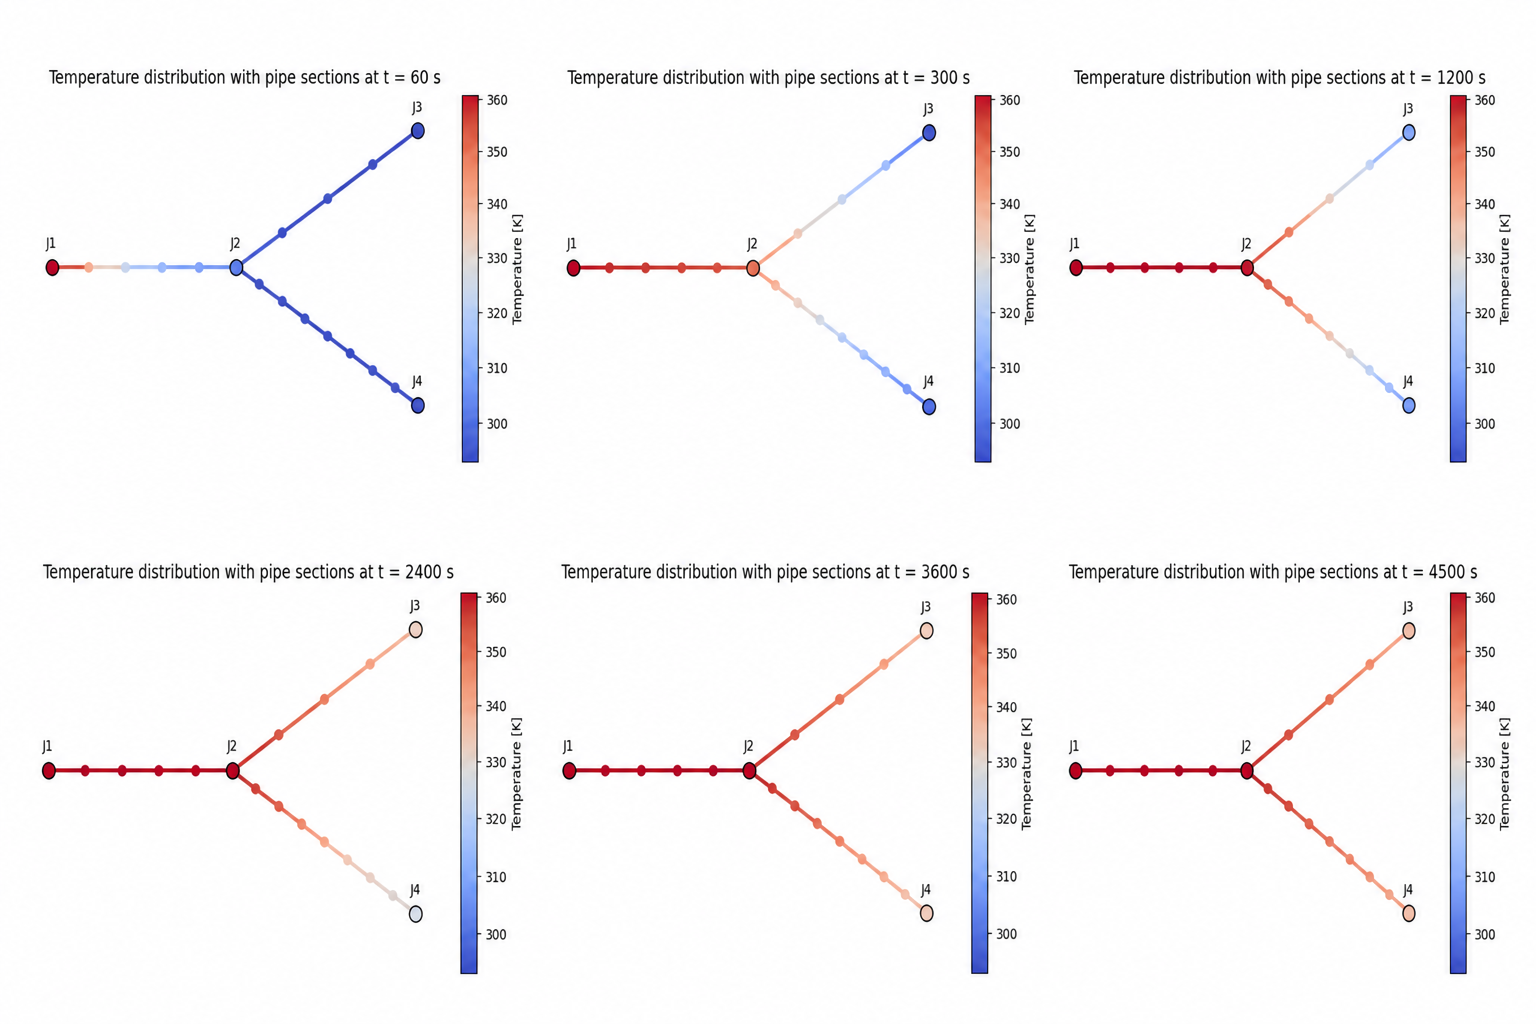
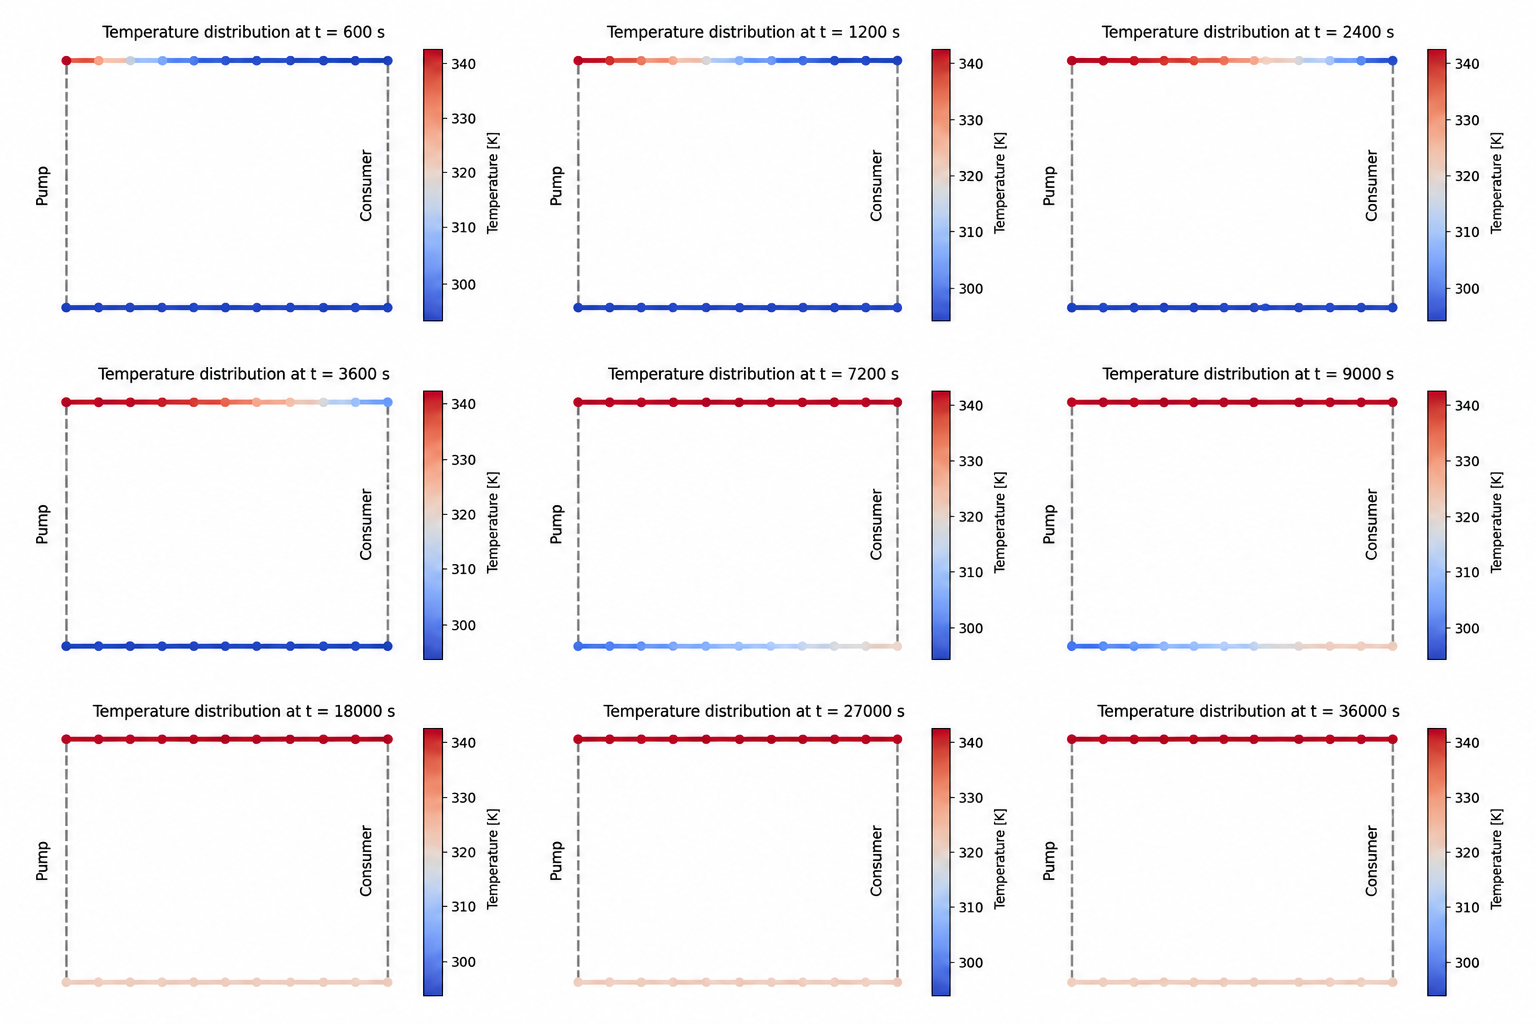
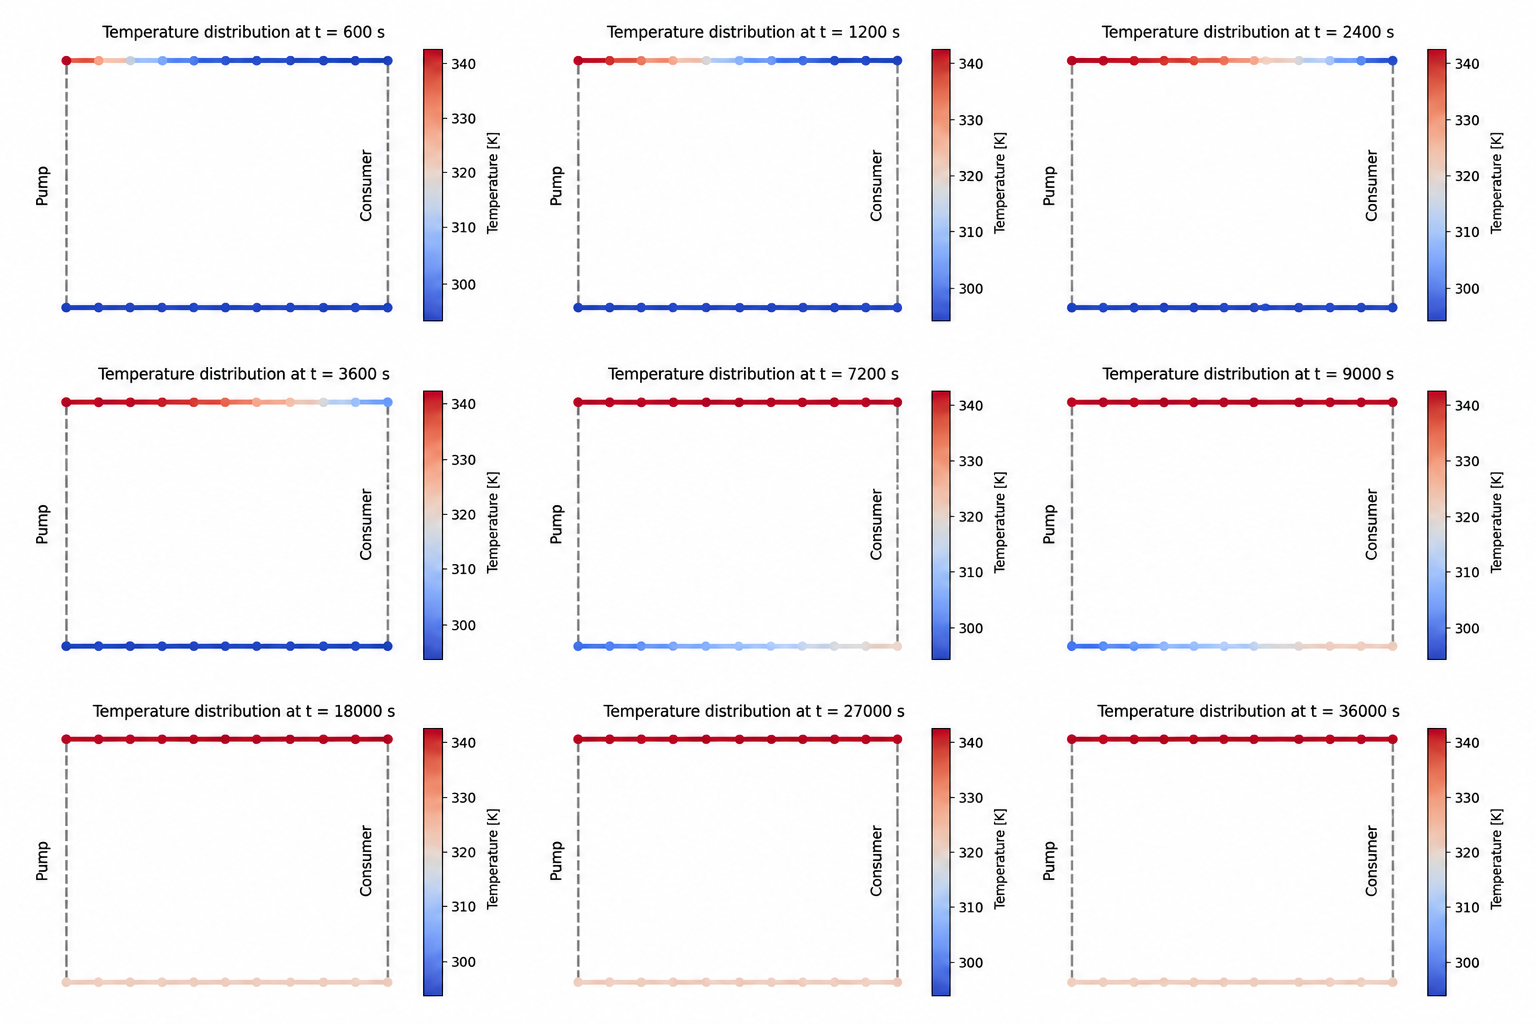
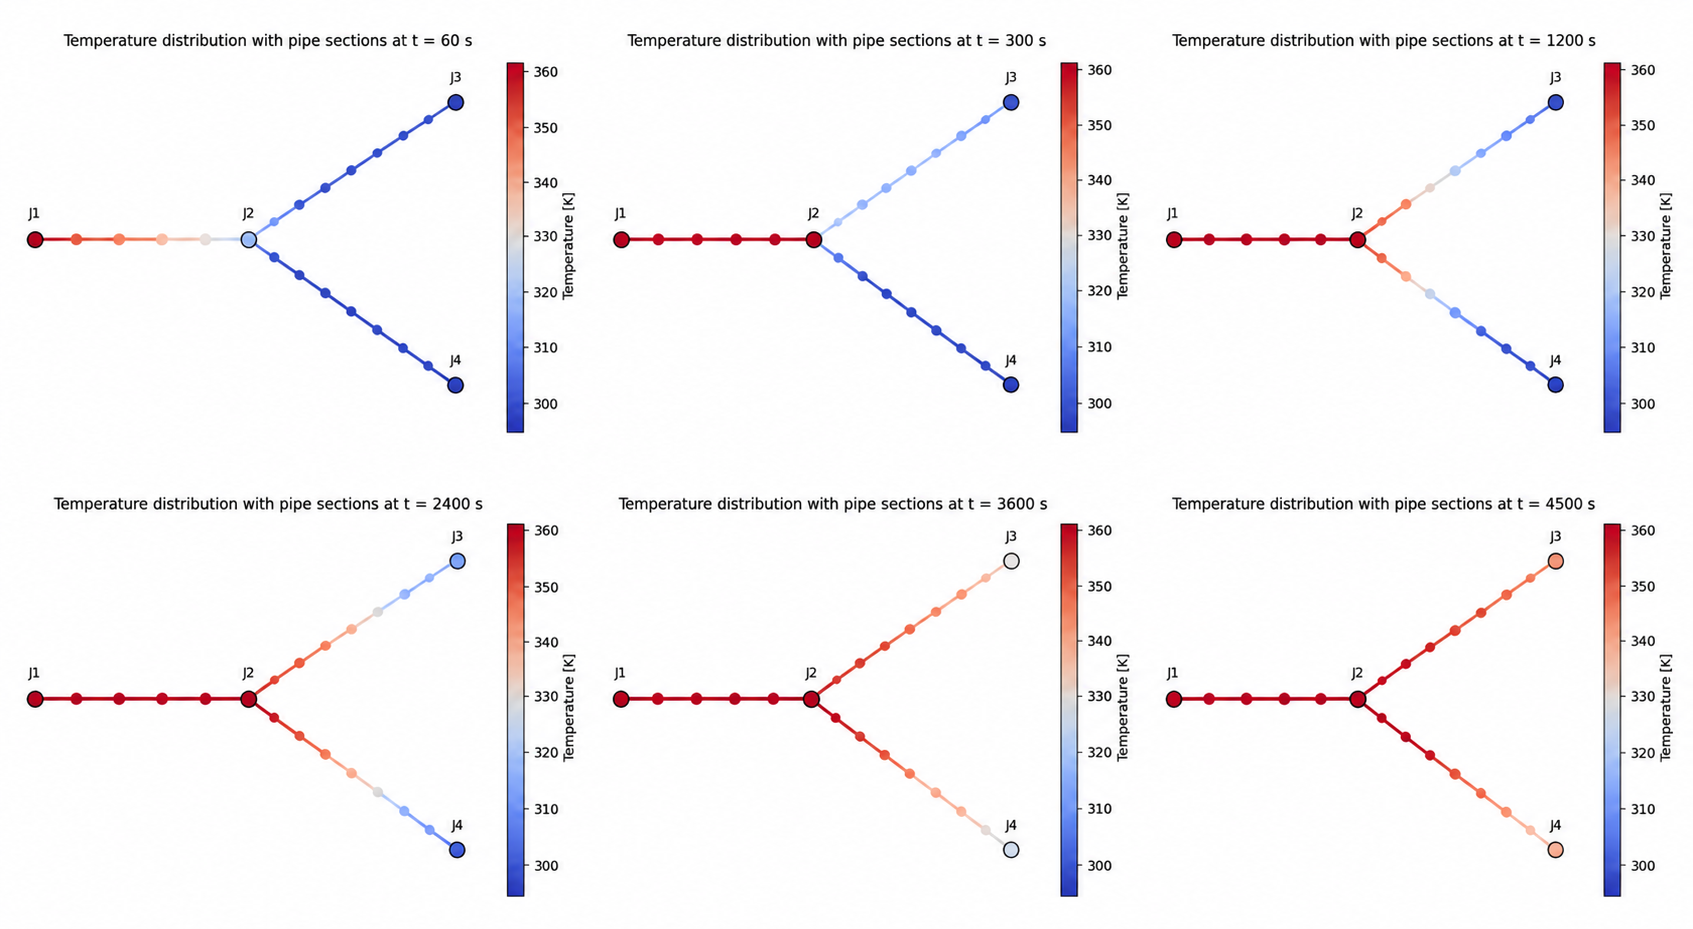

# Junction Temperatures During the Simulation

The following table shows the junction temperatures during the transient simulation.

In [21]:
ow._np_to_pd()
temp = ow.output["res_junction.t_k"]
selected_times = [60, 300, 1200, 2400, 3600, 4500, 5400, 7200, 9000]
rows = []
for zeit in selected_times:
    rows.append({
        "Zeit": zeit,
        "Junction 1": temp.loc[zeit, 0] - 273.15,
        "Junction 2": temp.loc[zeit, 1] - 273.15,
        "Junction 3": temp.loc[zeit, 2] - 273.15,
        "Junction 4": temp.loc[zeit, 3] - 273.15,
    })
temperature_table = pd.DataFrame(rows)
display(temperature_table.round(2))

,Zeit,Junction 1,Junction 2,Junction 3,Junction 4
0,60,90.0,45.69,20.00,20.00
1,300,90.0,85.33,20.01,19.99
2,1200,90.0,89.97,22.36,20.33
3,2400,90.0,89.97,35.40,28.52
4,3600,90.0,89.97,53.83,50.54
5,4500,90.0,89.97,65.87,67.35
6,5400,90.0,89.97,74.76,78.79
7,7200,90.0,89.97,84.25,87.68
8,9000,90.0,89.97,87.51,89.18


# Discussion

The results show a physically plausible transient temperature behavior. The junction close to the external grid heats up very quickly because hot water is directly injected into the network. The remaining junctions heat up more slowly because the thermal energy must first be transported through the pipes.

As time progresses, the temperature differences within the network decrease and the system gradually approaches a stationary thermal state. The temperature plots clearly illustrate how the thermal front propagates through the network and how the temperatures converge towards their final values.

The simulation was performed in sequential mode. Therefore, pandapipes solves the hydraulic and thermal equations consecutively at every time step. The transient behavior is introduced through the thermal equations, which take the temperatures from the previous time step into account. This creates a thermal storage effect and allows the gradual temperature evolution to be represented over time.

# Conclusion

This example demonstrates how transient thermal simulations can be performed in pandapipes for an open district heating network.

The simulation shows:
- transient temperature propagation,
- delayed heating of distant junctions,
- and the temperature evolution inside pipe sections.

Using transient=True together with pipe sections allows a simple visualization of thermal dynamics inside heating networks.